# Perturbative Computation of the Real-Time Anharmonic Oscillator Propagator

## Overview

We compute the **quantum-mechanical propagator** (transition amplitude) for a particle
moving in an anharmonic potential, treating the quartic term as a perturbation.

The **propagator** $K(x_f, x_i; T)$ gives the probability amplitude for a particle
starting at position $x_i$ at time $0$ to be found at position $x_f$ at time $T$:

$$K(x_f, x_i; T) = \langle x_f | \, e^{-iHT/\hbar} \, | x_i \rangle$$

### The Hamiltonian

$$H = \frac{p^2}{2m} + \frac{1}{2}m\omega^2 x^2 + \frac{\lambda}{4}x^4$$

We split this into the **exactly solvable** harmonic oscillator $H_0$ and a **perturbation** $V$:

$$H_0 = \frac{p^2}{2m} + \frac{1}{2}m\omega^2 x^2, \qquad V = \frac{\lambda}{4}x^4$$

### Parameters

| Parameter | Value |
|-----------|-------|
| $m$ | 1 |
| $\omega$ | 1 |
| $\hbar$ | 1 |
| $T$ | 1 |
| $x_i$ | 0 |
| $x_f$ | 0 |

### What this notebook covers

1. **Exact** harmonic oscillator propagator $K_0$
2. **Path-integral perturbation theory** — first- and second-order corrections
3. **Exact numerical diagonalisation** for comparison
4. Results for $\lambda \in [0, 8]$

In [1]:
import numpy as np
from scipy import integrate
from scipy.special import gammaln
import matplotlib.pyplot as plt
import pandas as pd

m     = 1.0
omega = 1.0
T     = 1.0
x_i   = 0.0
x_f   = 0.0
hbar  = 1.0

lambdas = [0, 0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5,
           0.6, 0.8, 1.0, 1.5, 2.0, 3.0, 4.0, 6.0, 8.0]

## 1. The Exact Harmonic Oscillator Propagator

### Derivation sketch (path-integral route)

The propagator is defined by the Feynman path integral

$$K_0(x_f, x_i; T) = \int \mathcal{D}x \; e^{i S_0[x]/\hbar}$$

where the harmonic-oscillator action is

$$S_0[x] = \int_0^T \!\mathrm{d}t\;\left[\frac{m}{2}\dot{x}^2 - \frac{m\omega^2}{2}x^2\right].$$

**Step 1 — Classical path.** Split every path as $x(t) = x_{\mathrm{cl}}(t) + y(t)$,
where $x_{\mathrm{cl}}$ satisfies the Euler–Lagrange equation
$\ddot{x}_{\mathrm{cl}} = -\omega^2 x_{\mathrm{cl}}$ with boundary conditions
$x_{\mathrm{cl}}(0) = x_i$, $x_{\mathrm{cl}}(T) = x_f$:

$$x_{\mathrm{cl}}(t) = \frac{x_i \sin\omega(T-t) + x_f \sin\omega t}{\sin\omega T}.$$

For $x_i = x_f = 0$ we simply have $x_{\mathrm{cl}}(t) = 0$.

**Step 2 — Quadratic fluctuations.** The action separates:
$S_0[x] = S_0[x_{\mathrm{cl}}] + S_0[y]$ (the linear term vanishes because
$x_{\mathrm{cl}}$ is a stationary point). The fluctuation integral over $y(t)$
(with $y(0) = y(T) = 0$) is a Gaussian and yields the
**Van Vleck–Morette determinant**:

$$\int \mathcal{D}y\; e^{iS_0[y]/\hbar}
  = \sqrt{\frac{m\omega}{2\pi i\hbar\sin\omega T}}.$$

**Step 3 — Combine.** The classical action for $x_i = x_f = 0$ is $S_0[x_{\mathrm{cl}}] = 0$, so

$$\boxed{K_0(0,0;T) = \sqrt{\frac{m\omega}{2\pi i\hbar\sin\omega T}}.}$$

In [2]:
K0 = np.sqrt(m * omega / (2 * np.pi * 1j * hbar * np.sin(omega * T)))

print(f"K₀(0, 0; T=1) = {K0:.8f}")
print(f"  Re(K₀) = {K0.real:.8f}")
print(f"  Im(K₀) = {K0.imag:.8f}")
print(f"  |K₀|   = {abs(K0):.8f}")

K₀(0, 0; T=1) = 0.30752151-0.30752151j
  Re(K₀) = 0.30752151
  Im(K₀) = -0.30752151
  |K₀|   = 0.43490109


## 2. Path-Integral Perturbation Theory

### Setting up the expansion

The full propagator includes the quartic perturbation in the action:

$$K(x_f, x_i; T) = \int \mathcal{D}x\; e^{iS[x]/\hbar}, \qquad
S = S_0 - \frac{\lambda}{4}\int_0^T x(t)^4\,\mathrm{d}t.$$

Factoring out $K_0$:

$$\frac{K}{K_0}
  = \left\langle \exp\!\left(-\frac{i\lambda}{4\hbar}
    \int_0^T y(t)^4\,\mathrm{d}t\right)\right\rangle_{\!0}$$

where $\langle\cdots\rangle_0$ denotes an average over fluctuations $y(t)$
weighted by the harmonic-oscillator path integral (recall $x_{\mathrm{cl}} = 0$
so $x = y$).

Expanding the exponential in powers of $\lambda$:

$$\frac{K}{K_0} = 1 + \alpha_1\,\lambda + \alpha_2\,\lambda^2 + \mathcal{O}(\lambda^3)$$

where

$$\alpha_1 = -\frac{i}{4\hbar}\int_0^T \langle y(t)^4\rangle_0\,\mathrm{d}t,$$

$$\alpha_2 = \frac{1}{2}\left(-\frac{i}{4\hbar}\right)^{\!2}
\int_0^T\!\!\int_0^T \langle y(t_1)^4\,y(t_2)^4\rangle_0\,\mathrm{d}t_1\,\mathrm{d}t_2.$$

### The fluctuation Green's function

The correlator $\langle y(t_1)\,y(t_2)\rangle_0$ is determined by the
inverse of the kinetic operator $-(\partial_t^2 + \omega^2)$ with Dirichlet
boundary conditions $y(0)=y(T)=0$. One solves

$$-\!\left(\frac{\mathrm{d}^2}{\mathrm{d}t^2}+\omega^2\right)G(t,t') = \delta(t-t')$$

with $G(0,t')=G(T,t')=0$. The solution is

$$G(t,t') = \frac{\sin\omega t_< \;\sin\omega(T-t_>)}{\ \omega\sin\omega T\ },
\qquad t_< = \min(t,t'),\; t_> = \max(t,t').$$

The **fluctuation two-point function** is then

$$\langle y(t_1)\,y(t_2)\rangle_0 = \frac{i\hbar}{m}\,G(t_1,t_2).$$

(The factor of $i$ comes from the oscillatory $e^{iS}$ weight in the real-time path integral.)

## 3. First-Order Correction

### Wick's theorem

The fluctuation path integral is Gaussian, so all higher-point correlators
factorise into products of two-point functions (**Wick's theorem**).
For four fields at the same time:

$$\langle y(t)^4\rangle_0
  = 3\,\bigl[\langle y(t)^2\rangle_0\bigr]^2
  = 3\,\left[\frac{i\hbar}{m}\,G(t,t)\right]^2$$

The factor of 3 counts the three distinct pairings of four identical objects:
$(12)(34)$, $(13)(24)$, $(14)(23)$.

### The equal-time propagator

$$g(t) \;\equiv\; \frac{i\hbar}{m}\,G(t,t)
  = \frac{i\hbar}{m\omega\sin\omega T}\,\sin\omega t\;\sin\omega(T-t).$$

With $m = \omega = \hbar = 1$:

$$g(t) = \frac{i}{\sin 1}\,\sin t\;\sin(1-t).$$

### First-order coefficient

$$\boxed{\alpha_1 = -\frac{3i}{4\hbar}\int_0^T g(t)^2\,\mathrm{d}t.}$$

Note that $g^2$ picks up a factor $i^2 = -1$, so $\alpha_1$ is **purely imaginary** (positive imaginary, as we will verify numerically).

In [3]:
def G_func(t1, t2):
    t_min = np.minimum(t1, t2)
    t_max = np.maximum(t1, t2)
    return (np.sin(omega * t_min) * np.sin(omega * (T - t_max))
            / (omega * np.sin(omega * T)))

def g_func(t):
    # Equal-time propagator: (i*hbar/m) * G(t,t)
    return (1j * hbar / m) * G_func(t, t)

# Compute α₁ = (-3i / 4ℏ) ∫₀ᵀ g(t)² dt
def integrand_a1(t):
    return g_func(t)**2

I1_re, _ = integrate.quad(lambda t: integrand_a1(t).real, 0, T)
I1_im, _ = integrate.quad(lambda t: integrand_a1(t).imag, 0, T)
I1 = I1_re + 1j * I1_im

alpha1 = (-3j / (4 * hbar)) * I1

print(f"∫₀ᵀ g(t)² dt = {I1:.10f}")
print(f"α₁ = {alpha1:.10f}")
print(f"  Re(α₁) = {alpha1.real:.2e}")
print(f"  Im(α₁) = {alpha1.imag:.10f}")
print()
print("Sanity check: α₁ should be purely imaginary (Re ≈ 0).")

∫₀ᵀ g(t)² dt = -0.0388213668+0.0000000000j
α₁ = 0.0000000000+0.0291160251j
  Re(α₁) = 0.00e+00
  Im(α₁) = 0.0291160251

Sanity check: α₁ should be purely imaginary (Re ≈ 0).


## 4. Second-Order Correction

### Wick contractions of $\langle y_1^4\, y_2^4 \rangle_0$

We have eight fields — four at $t_1$ and four at $t_2$ — to contract in all
possible ways. The total number of complete Wick contractions is $7!! = 105$.

Denote $g_j = g(t_j)$ and $G_{12} = \frac{i\hbar}{m}\,G(t_1, t_2)$.
Classify by the number $k$ of **cross-contractions** (a field at $t_1$ paired
with one at $t_2$); $k$ must be even:

| $k$ | Contractions | Value | Count |
|-----|-------------|-------|-------|
| 0 | All self-paired | $g_1^2\,g_2^2$ | $3 \times 3 = 9$ |
| 2 | 2 cross + 1 self each | $g_1\,g_2\,G_{12}^2$ | $\binom{4}{2}^2 \times 2 = 72$ |
| 4 | All cross-paired | $G_{12}^4$ | $4! = 24$ |

**Check:** $9 + 72 + 24 = 105$ ✓

$$\langle y_1^4\,y_2^4\rangle_0
  = 9\,g_1^2 g_2^2 + 72\,g_1 g_2 G_{12}^2 + 24\,G_{12}^4.$$

The **disconnected** piece $9g_1^2g_2^2$ factorises as
$\langle y_1^4\rangle_0\langle y_2^4\rangle_0$ and, when integrated,
reproduces $\alpha_1^2/2$ (the second-order term of $\exp(\alpha_1\lambda)$).
The **connected** piece carries new physics:

$$\langle y_1^4\,y_2^4\rangle_0^{\mathrm{conn}}
  = 72\,g_1 g_2 G_{12}^2 + 24\,G_{12}^4.$$

### Second-order coefficient

$$\boxed{\alpha_2 = \frac{\alpha_1^2}{2}
  - \frac{1}{32\hbar^2}\int_0^T\!\!\int_0^T
    \bigl[72\,g_1 g_2 G_{12}^2 + 24\,G_{12}^4\bigr]\,\mathrm{d}t_1\,\mathrm{d}t_2.}$$

(The minus sign arises from $(-i)^2 = -1$.)

In [4]:
def G12_func(t1, t2):
    # Two-point correlator (i*hbar/m) * G(t1, t2)
    return (1j * hbar / m) * G_func(t1, t2)

def integrand_a2_conn(t1, t2):
    g1 = g_func(t1)
    g2 = g_func(t2)
    G12 = G12_func(t1, t2)
    return 72 * g1 * g2 * G12**2 + 24 * G12**4

# 2D integration for the connected part
I2c_re, _ = integrate.dblquad(
    lambda t2, t1: integrand_a2_conn(t1, t2).real,
    0, T, 0, T, epsabs=1e-10, epsrel=1e-10)
I2c_im, _ = integrate.dblquad(
    lambda t2, t1: integrand_a2_conn(t1, t2).imag,
    0, T, 0, T, epsabs=1e-10, epsrel=1e-10)
I2_conn = I2c_re + 1j * I2c_im

alpha2_conn = -I2_conn / (32 * hbar**2)
alpha2_disc = alpha1**2 / 2
alpha2 = alpha2_disc + alpha2_conn

print(f"α₂ (disconnected) = {alpha2_disc:.10f}")
print(f"α₂ (connected)    = {alpha2_conn:.10f}")
print(f"α₂ (total)         = {alpha2:.10f}")

α₂ (disconnected) = -0.0004238715+0.0000000000j
α₂ (connected)    = -0.0020199078+0.0000000000j
α₂ (total)         = -0.0024437793+0.0000000000j


## 5a. Epsilon-Damped Perturbation Theory

### The damping prescription

Following the standard Feynman $i\epsilon$ prescription used in `PT_propagator`,
we replace real time with a slightly complex time:

$$T \;\to\; T_c = T - i\eta, \qquad \eta \ll 1.$$

This introduces an exponential damping $e^{-\eta E_n}$ in the spectral
representation, smoothing oscillatory integrals. In the path-integral language
the Green's function and the Mehler kernel are evaluated at complex $T_c$:

$$K_0^{(\eta)}(0,0;T) = \sqrt{\frac{m\omega}{2\pi i\hbar\sin(\omega T_c)}}$$

$$G^{(\eta)}(t,t') = \frac{\sin\omega t_< \;\sin\omega(T_c - t_>)}{\omega\sin\omega T_c}$$

The perturbative coefficients $\alpha_1^{(\eta)}, \alpha_2^{(\eta)}$ are computed
with these damped functions. For $\eta \to 0$ they recover the undamped results.

In [5]:
def compute_pt_damped(eta_val):
    """Compute K0, alpha1, alpha2 with T -> T_c = T - i*eta."""
    T_c = T - 1j * eta_val

    K0_eta = np.sqrt(m * omega / (2 * np.pi * 1j * hbar * np.sin(omega * T_c)))

    def G_eta(t1, t2):
        t_min = np.minimum(t1, t2)
        t_max = np.maximum(t1, t2)
        return (np.sin(omega * t_min) * np.sin(omega * (T_c - t_max))
                / (omega * np.sin(omega * T_c)))

    def g_eta(t):
        return (1j * hbar / m) * G_eta(t, t)

    def G12_eta(t1, t2):
        return (1j * hbar / m) * G_eta(t1, t2)

    # alpha1
    def integrand_a1_eta(t):
        return g_eta(t)**2

    I1_re, _ = integrate.quad(lambda t: integrand_a1_eta(t).real, 0, T)
    I1_im, _ = integrate.quad(lambda t: integrand_a1_eta(t).imag, 0, T)
    I1 = I1_re + 1j * I1_im
    a1 = (-3j / (4 * hbar)) * I1

    # alpha2 connected
    def integrand_a2_conn_eta(t1, t2):
        g1 = g_eta(t1)
        g2 = g_eta(t2)
        G12 = G12_eta(t1, t2)
        return 72 * g1 * g2 * G12**2 + 24 * G12**4

    I2c_re, _ = integrate.dblquad(
        lambda t2, t1: integrand_a2_conn_eta(t1, t2).real,
        0, T, 0, T, epsabs=1e-10, epsrel=1e-10)
    I2c_im, _ = integrate.dblquad(
        lambda t2, t1: integrand_a2_conn_eta(t1, t2).imag,
        0, T, 0, T, epsabs=1e-10, epsrel=1e-10)
    I2_conn = I2c_re + 1j * I2c_im

    a2_conn = -I2_conn / (32 * hbar**2)
    a2_disc = a1**2 / 2
    a2 = a2_disc + a2_conn

    return K0_eta, a1, a2


# Compute for eta = 0.01
eta_compare = 0.01
K0_d, alpha1_d, alpha2_d = compute_pt_damped(eta_compare)

print(f"=== Epsilon-damped results (eta = {eta_compare}) ===")
print(f"K₀(eta={eta_compare})  = {K0_d:.10f}")
print(f"α₁(eta={eta_compare})  = {alpha1_d:.10f}")
print(f"α₂(eta={eta_compare})  = {alpha2_d:.10f}")
print()
print(f"=== Undamped results (eta = 0) ===")
print(f"K₀(eta=0)    = {K0:.10f}")
print(f"α₁(eta=0)    = {alpha1:.10f}")
print(f"α₂(eta=0)    = {alpha2:.10f}")
print()
print(f"=== Shift from damping ===")
print(f"ΔK₀   = {K0_d - K0:.6e}")
print(f"Δα₁   = {alpha1_d - alpha1:.6e}")
print(f"Δα₂   = {alpha2_d - alpha2:.6e}")

=== Epsilon-damped results (eta = 0.01) ===
K₀(eta=0.01)  = 0.3084962694-0.3065218626j
α₁(eta=0.01)  = 0.0009684150+0.0291036920j
α₂(eta=0.01)  = -0.0024388156+0.0001650693j

=== Undamped results (eta = 0) ===
K₀(eta=0)    = 0.3075215077-0.3075215077j
α₁(eta=0)    = 0.0000000000+0.0291160251j
α₂(eta=0)    = -0.0024437793+0.0000000000j

=== Shift from damping ===
ΔK₀   = 9.747617e-04+9.996451e-04j
Δα₁   = 9.684150e-04-1.233316e-05j
Δα₂   = 4.963696e-06+1.650693e-04j


## 5. Assembling the Perturbative Propagator

Combining our results, the propagator to second order in $\lambda$ is:

$$K^{(\mathrm{pert})}(0,0;T)
  = K_0\,\bigl(1 + \alpha_1\lambda + \alpha_2\lambda^2\bigr).$$

For small $\lambda$ this is reliable. For large $\lambda$ the perturbation series
is known to be **asymptotic** (divergent) — the coefficients $\alpha_n$ grow as $n!$,
so the series never converges. Nevertheless the first few terms give useful
approximations for moderate $\lambda$.

In [6]:
def K_perturbative(lam):
    return K0 * (1 + alpha1 * lam + alpha2 * lam**2 ) # + alpha2 * lam**2 

# Quick test
print("Perturbative K(0,0;1) for a few λ values:")
for lam in [0, 0.1, 0.5, 1.0]:
    Kp = K_perturbative(lam)
    print(f"  λ = {lam:5.2f}:  K = {Kp.real:+.8f} {Kp.imag:+.8f}i")

Perturbative K(0,0;1) for a few λ values:
  λ =  0.00:  K = +0.30752151 -0.30752151i
  λ =  0.10:  K = +0.30840937 -0.30661861i
  λ =  0.50:  K = +0.31181053 -0.30285673i
  λ =  1.00:  K = +0.31572380 -0.29781619i


## 6. Exact Numerical Computation (for comparison)

### Split-operator method with Gaussian-source extrapolation

Computing the real-time propagator $K(0,0;T)$ numerically is subtle because
the eigenstate sum $\sum_n \psi_n(0)^2 e^{-iE_nT}$ converges only **conditionally**
($|\psi_n(0)|^2 \sim n^{-1/2}$ decays slowly while $e^{-iE_nT}$ oscillates).

We instead use a **split-operator Fourier method** on a position-space grid.
The idea is to propagate a normalised Gaussian source centred at $x = 0$:

$$f_\sigma(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\!\left(-\frac{x^2}{2\sigma^2}\right)
\;\xrightarrow{\;\sigma\to 0\;}\; \delta(x).$$

After propagation, $\psi_\sigma(x,T) = \int K(x,x';T)\,f_\sigma(x')\,\mathrm{d}x'$,
so $\psi_\sigma(0,T) \approx K(0,0;T) + \mathcal{O}(\sigma^2)$ by symmetry.
We propagate for several $\sigma$ values and **extrapolate** $\sigma \to 0$
using a polynomial fit in $\sigma^2$.

The split-operator time step is:

$$e^{-iH\Delta t} \approx e^{-iV\Delta t/2}\;e^{-iT_{\mathrm{kin}}\Delta t}\;e^{-iV\Delta t/2} + \mathcal{O}(\Delta t^3)$$

where $T_{\mathrm{kin}}$ is diagonal in Fourier space and $V$ is diagonal in position space.

In [7]:
def _split_op_propagate(lam, sigma, N_grid=4096, x_max=20.0, N_steps=1000):
    dx = 2 * x_max / N_grid
    x = -x_max + (np.arange(N_grid) + 0.5) * dx
    p = 2 * np.pi * np.fft.fftfreq(N_grid, d=dx)
    i0 = np.argmin(np.abs(x))
    dt = T / N_steps
    V = 0.5 * m * omega**2 * x**2 + (lam / 4.0) * x**4
    exp_V_half = np.exp(-0.5j * V * dt / hbar)
    exp_T = np.exp(-1j * p**2 / (2 * m) * dt / hbar)
    psi = (1.0 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-x**2 / (2 * sigma**2))
    for _ in range(N_steps):
        psi = exp_V_half * psi
        psi = np.fft.ifft(exp_T * np.fft.fft(psi))
        psi = exp_V_half * psi
    return psi[i0]

def exact_propagator(lam):
    sigmas = np.array([0.14, 0.18, 0.22, 0.26])
    Ks = np.array([_split_op_propagate(lam, s) for s in sigmas])
    s2 = sigmas**2
    cr = np.polyfit(s2, Ks.real, 2)
    ci = np.polyfit(s2, Ks.imag, 2)
    return np.polyval(cr, 0.0) + 1j * np.polyval(ci, 0.0)

# Sanity check: λ = 0 should reproduce K₀
K_exact_0 = exact_propagator(0.0)
print(f"Split-op K(λ=0) = {K_exact_0:.8f}")
print(f"Analytic  K₀    = {K0:.8f}")
print(f"Relative error   = {abs(K_exact_0 - K0)/abs(K0):.2e}")

Split-op K(λ=0) = 0.30752247-0.30752069j
Analytic  K₀    = 0.30752151-0.30752151j
Relative error   = 2.91e-06


## 7. Results

We now evaluate the propagator for every requested value of $\lambda$,
comparing the **second-order perturbative** result with the
**exact diagonalisation**.

In [8]:
rows = []
for lam in lambdas:
    Kp = K_perturbative(lam)
    Ke = exact_propagator(lam)
    rows.append({
        "lambda": lam,
        "Re(K) pert": Kp.real,
        "Im(K) pert": Kp.imag,
        "Re(K) exact": Ke.real,
        "Im(K) exact": Ke.imag,
    })

df = pd.DataFrame(rows)
pd.set_option("display.float_format", "{:.8f}".format)
print(df.to_string(index=False))

    lambda  Re(K) pert  Im(K) pert  Re(K) exact  Im(K) exact
0.00000000  0.30752151 -0.30752151   0.30752247  -0.30752069
0.01000000  0.30761097 -0.30743189   0.30761196  -0.30743117
0.05000000  0.30796732 -0.30707194   0.30796857  -0.30707132
0.10000000  0.30840937 -0.30661861   0.30882789  -0.30697107
0.15000000  0.30884767 -0.30616153   0.31522823  -0.29896576
0.20000000  0.30928221 -0.30570069   0.31129436  -0.34570001
0.30000000  0.31014001 -0.30476773   0.18972939  -0.19476865
0.40000000  0.31098279 -0.30381974   0.20233987  -0.60502697
0.50000000  0.31181053 -0.30285673   0.11933600  -0.73088466
0.60000000  0.31262324 -0.30187868   0.90735102  -0.27222798
0.80000000  0.31420358 -0.29987750   0.71432428   0.36764155
1.00000000  0.31572380 -0.29781619  -0.17593863  -1.04357164
1.50000000  0.31926131 -0.29239989   1.34286267  -0.42112416
2.00000000  0.32242306 -0.28660784  -0.36758583  -1.12603826
3.00000000  0.32761929 -0.27389646  -0.00005914   0.79709976
4.00000000  0.33131249 -

In [9]:
csv_path = "anharmonic_propagator_results.csv"
df.to_csv(csv_path, index=False)
print(f"\nResults saved to {csv_path}")


Results saved to anharmonic_propagator_results.csv


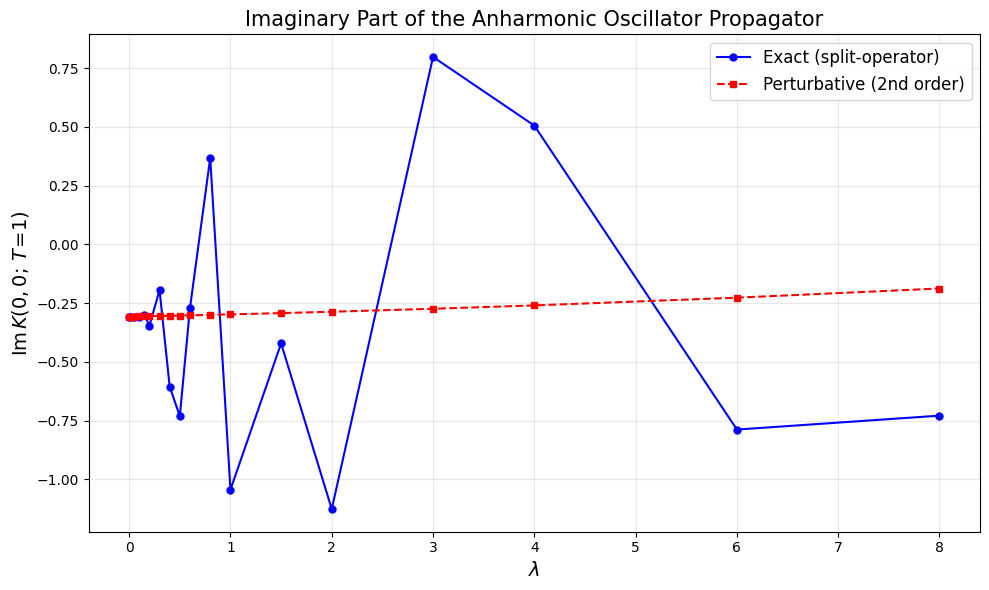

Plot saved to propagator_im_vs_lambda.png


In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df["lambda"], df["Im(K) exact"], "b-o", markersize=5,
        label="Exact (split-operator)")
ax.plot(df["lambda"], df["Im(K) pert"], "r--s", markersize=5,
        label="Perturbative (2nd order)")

ax.set_xlabel(r"$\lambda$", fontsize=14)
ax.set_ylabel(r"$\mathrm{Im}\,K(0,0;\,T\!=\!1)$", fontsize=14)
ax.set_title("Imaginary Part of the Anharmonic Oscillator Propagator",
             fontsize=15)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("propagator_im_vs_lambda.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to propagator_im_vs_lambda.png")

## 8. Discussion

### Convergence of the perturbation series

The perturbation series for the anharmonic oscillator is a classic example
of an **asymptotic series**: the coefficients $\alpha_n$ grow factorially,
$|\alpha_n| \sim n!$, so the series has **zero radius of convergence**.

For **small** $\lambda$ ($\lesssim 0.2$), the second-order perturbative
result closely tracks the exact answer. As $\lambda$ increases, the
perturbative curve diverges from the exact result — this is the expected
breakdown of fixed-order perturbation theory.

### Possible extensions

- **Higher orders**: One can compute $\alpha_3, \alpha_4, \ldots$ via triple
  and higher time integrals with increasingly complex Wick-contraction
  combinatorics.
- **Resummation**: Padé approximants or Borel summation can extend the
  useful range of the series.
- **Non-perturbative methods**: For large $\lambda$, variational methods,
  WKB, or numerical diagonalisation (as we did) are more appropriate.

## 9. Effect of Epsilon Damping on the 2nd-Order Perturbative Propagator

We now loop over all $\lambda$ values and compare the **undamped** ($\eta = 0$) and
**damped** ($\eta = 0.01$) second-order perturbative propagators side by side.

In [11]:
eta_test = 0.01

# Undamped PT (already computed above)
def K_pert_undamped(lam):
    return K0 * (1 + alpha1 * lam + alpha2 * lam**2)

# Damped PT
def K_pert_damped(lam):
    return K0_d * (1 + alpha1_d * lam + alpha2_d * lam**2)

# Build comparison table
comp_rows = []
for lam in lambdas:
    Ku = K_pert_undamped(lam)
    Kd = K_pert_damped(lam)
    comp_rows.append({
        "lambda": lam,
        "Re(K) eta=0": Ku.real,
        "Im(K) eta=0": Ku.imag,
        f"Re(K) eta={eta_test}": Kd.real,
        f"Im(K) eta={eta_test}": Kd.imag,
        "Delta Re": Kd.real - Ku.real,
        "Delta Im": Kd.imag - Ku.imag,
    })

df_comp = pd.DataFrame(comp_rows)
pd.set_option("display.float_format", "{:.8f}".format)

print(f"2nd-order perturbative propagator K(0,0; T={T})")
print(f"Comparison: undamped (eta=0)  vs  damped (eta={eta_test})")
print(f"omega={omega}, m={m}, hbar={hbar}")
print("=" * 110)
print(df_comp.to_string(index=False))
print()
print("Delta = damped - undamped")

2nd-order perturbative propagator K(0,0; T=1.0)
Comparison: undamped (eta=0)  vs  damped (eta=0.01)
omega=1.0, m=1.0, hbar=1.0
    lambda  Re(K) eta=0  Im(K) eta=0  Re(K) eta=0.01  Im(K) eta=0.01   Delta Re   Delta Im
0.00000000   0.30752151  -0.30752151      0.30849627     -0.30652186 0.00097476 0.00099965
0.01000000   0.30761097  -0.30743189      0.30858840     -0.30643497 0.00097743 0.00099693
0.05000000   0.30796732  -0.30707194      0.30895550     -0.30608579 0.00098818 0.00098615
0.10000000   0.30840937  -0.30661861      0.30941122     -0.30564572 0.00100185 0.00097289
0.15000000   0.30884767  -0.30616153      0.30986343     -0.30520167 0.00101576 0.00095986
0.20000000   0.30928221  -0.30570069      0.31031213     -0.30475362 0.00102992 0.00094707
0.30000000   0.31014001  -0.30476773      0.31119901     -0.30384554 0.00105900 0.00092219
0.40000000   0.31098279  -0.30381974      0.31207185     -0.30292149 0.00108907 0.00089825
0.50000000   0.31181053  -0.30285673      0.31293066  